In [20]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from scipy import stats

In [21]:
df_download = pd.read_csv('merged_crime_data.csv')
df_download

,Incident Category,Incident Description,Police District,Incident Date,Incident Time,Incident Day of Week,Longitude,Latitude,Incident Year
0,Motor Vehicle Theft,Stolen Automobile,Taraval,2016/03/03,19:30,Thursday,-122.463545,37.707968,2016
1,Motor Vehicle Theft,Stolen Truck,Mission,2014/12/26,15:30,Friday,-122.424435,37.755900,2014
2,Missing Person,Missing Adult,Park,2014/11/24,10:00,Monday,-122.437536,37.777844,2014
3,Missing Person,Missing Adult,Southern,2015/03/06,20:00,Friday,-122.396759,37.773173,2015
4,Larceny Theft,Grand Theft From Locked Auto,Southern,2005/10/21,10:15,Friday,-120.500000,90.000000,2005
...,...,...,...,...,...,...,...,...,...
1661422,Larceny Theft,"Theft, From Unlocked Vehicle, >$950",Northern,2025/01/03,00:00,Friday,NaN,NaN,2025
1661423,Larceny Theft,"Theft, Other Property, $50-$200",Northern,2025/01/06,06:24,Monday,NaN,NaN,2025
1661424,Larceny Theft,"Theft, Other Property, >$950",Taraval,2024/12/21,11:13,Saturday,NaN,NaN,2024
1661425,Larceny Theft,"Theft, Other Property, $50-$200",Taraval,2025/01/07,12:00,Tuesday,NaN,NaN,2025


Basic data cleaning - droping nan values, duplicates, checking date range, attribute types

In [22]:
df = df_download.copy()
df.isna().sum()

Incident Category           0
Incident Description        0
Police District             1
Incident Date               0
Incident Time               0
Incident Day of Week        0
Longitude               32026
Latitude                32026
Incident Year               0
dtype: int64

In [23]:
df.dropna(inplace=True)

In [24]:
print(df.shape)
df.drop_duplicates(inplace=True)
print(df.shape)

(1629400, 9)
(1607420, 9)
(1607420, 9)


In [25]:
df.dtypes

Incident Category           str
Incident Description        str
Police District             str
Incident Date               str
Incident Time               str
Incident Day of Week        str
Longitude               float64
Latitude                float64
Incident Year             int64
dtype: object

In [26]:
print(df['Incident Date'].min() ,df['Incident Date'].max())
df = df[df['Incident Year'] != 2026]
print(df['Incident Date'].min() ,df['Incident Date'].max())

2003/01/01 2026/02/01
2003/01/01 2025/12/31
2003/01/01 2025/12/31


Let's also drop observations for the police district noted as 'Out of SF'. These records are irrelevant for the further analysis, as this district's incident count is significantly lower than other districts and it does not fall into the analysis of the city itself, as it is not specified what 'Out of SF' means in practice (geographically).

In [27]:
df['Police District'].value_counts()

Police District
Southern      259918
Northern      234263
Central       205093
Mission       199324
Bayview       138790
Ingleside     130379
Tenderloin    130000
Taraval       120474
Richmond       94673
Park           88823
Out of SF       2702
Name: count, dtype: int64

In [28]:
df = df[df['Police District'] != 'Out of SF']
df['Police District'].value_counts()

Police District
Southern      259918
Northern      234263
Central       205093
Mission       199324
Bayview       138790
Ingleside     130379
Tenderloin    130000
Taraval       120474
Richmond       94673
Park           88823
Name: count, dtype: int64

# Assignment 1.1 - Temporal overview

# Assignment 1.2 - Crime profiles by police district

This part of the assignment focuses on investigating the crime categories within individual police districts by comparing their....

We compute the ratio of a crime probability within in a district relative to its probability within the full dataset. This measure allows to identify specific crime characteristics of the police districts in San Francisco. Here we address the following assignment question:

> * For each police district in your dataset, compute the **conditional crime profile**: for each of your Personal Focus Crimes, calculate
>
>   $$r(\text{crime}, \text{district}) = \frac{P(\text{crime} \mid \text{district})}{P(\text{crime})}$$
>
>   A value above 1 means that crime type is *over-represented* in that district relative to the city-wide average; below 1 means it is *under-represented*.

First, we calculate P(crime) - probability of a crime type happening within the full dataset.

In [29]:
p_crimes = {}

for crime in df["Incident Category"].unique():
    crime_cnt = df[df['Incident Category'] == crime].shape[0]
    total_cnt = df.shape[0]
    p_crimes[crime] = crime_cnt/total_cnt

p_crimes

{'Motor Vehicle Theft': 0.11025780137438293,
 'Missing Person': 0.04008398382505992,
 'Larceny Theft': 0.4489195167496287,
 'Arson': 0.004117405042151114,
 'Robbery': 0.04650888379303219,
 'Vandalism': 0.11122674946011736,
 'Weapon Laws': 0.020366639467028606,
 'Burglary': 0.08808499772434551,
 'Drug Violation': 0.09108923624789837,
 'Stolen Property': 0.009822461490244653,
 'Forgery And Counterfeiting': 0.016289191046969635,
 'Prostitution': 0.010684650476326638,
 'Embezzlement': 0.0025484833028143823}

Then we calculate P(crime | district) - probability of a crime type happening in each district individually. The variable p_crimes_pds is a dictionary with police districts as the keys and lists of tuples with a crime category and a associated probability as the values. 

In [30]:
p_crimes_pds = {}

for police_dis in df['Police District'].unique():
    p_crimes_pd = []
    total_pd_cnt = df[df['Police District'] == police_dis].shape[0]

    for crime in df['Incident Category'].unique():
        crime_pd_cnt = df[(df['Police District'] == police_dis) & (df['Incident Category'] == crime)].shape[0]
        p_crime_pd = crime_pd_cnt/total_pd_cnt
        p_crimes_pd.append((crime, p_crime_pd))

    p_crimes_pds[police_dis] = p_crimes_pd

p_crimes_pds

{'Taraval': [('Motor Vehicle Theft', 0.15834121885220048),
  ('Missing Person', 0.05608679051081561),
  ('Larceny Theft', 0.42247289871673555),
  ('Arson', 0.003901256702691037),
  ('Robbery', 0.035526337633016256),
  ('Vandalism', 0.13666849278682539),
  ('Weapon Laws', 0.01478327273934625),
  ('Burglary', 0.10863754835068147),
  ('Drug Violation', 0.02950844165546093),
  ('Stolen Property', 0.00664873748692664),
  ('Forgery And Counterfeiting', 0.021573119511263842),
  ('Prostitution', 0.0032289124624400286),
  ('Embezzlement', 0.002622972591596527)],
 'Mission': [('Motor Vehicle Theft', 0.12031165338845297),
  ('Missing Person', 0.0412143043486986),
  ('Larceny Theft', 0.3723836567598483),
  ('Arson', 0.004214244145210813),
  ('Robbery', 0.06023860648993598),
  ('Vandalism', 0.11089984146414883),
  ('Weapon Laws', 0.02640424635267203),
  ('Burglary', 0.07947863779574964),
  ('Drug Violation', 0.11569103570066826),
  ('Stolen Property', 0.010686119082498845),
  ('Forgery And Counterf

Finally, we calculate the ratio P(crime | district) / P(crime). The variable p_crimes_pds_crimes is a dictionary with police districts as the keys and lists of tuples with a crime category and a associated probability as the values. As this variable is analogical to one in the previous code cell (p_crimes_pds), its content was not printed for the brevity and cleanliness of the report.

In [31]:
p_crimes_pds_crimes = {}

for police_dis in df['Police District'].unique():
    p_crimes_pd_crimes_early = []

    for crime, p in p_crimes_pds[police_dis]:
        p_crime_pd_crime = p / p_crimes[crime]
        p_crimes_pd_crimes_early.append((crime, p_crime_pd_crime))
    
    p_crimes_pds_crimes[police_dis] = p_crimes_pd_crimes_early

Next, we visualize the ratios and so we address the following assignment question:

> * Visualize these ratios in a way that makes it easy to compare across both districts and crime types. (Simple barcharts are fine, but you may also use ideas from more complex visualization techniques, for example, a heatmap could work well here, but you're free to choose another format if you can justify it.)

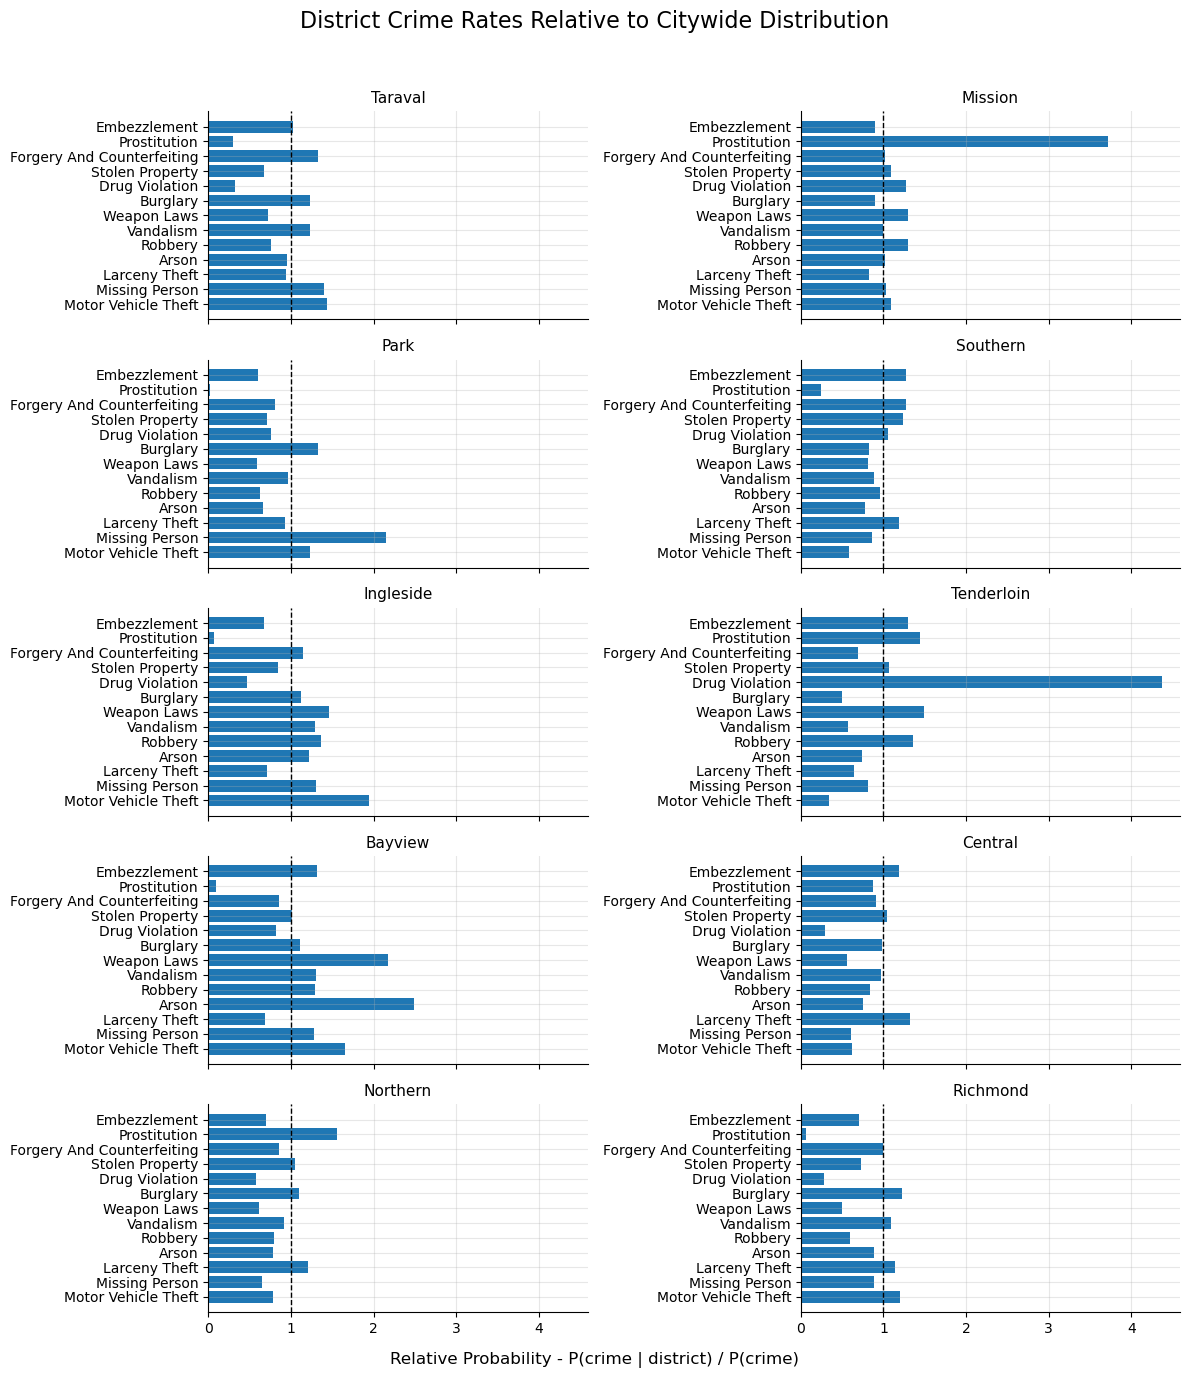

In [32]:
fig, axs = plt.subplots(5, 2, figsize = (12, 14), sharex=True)
fig.suptitle('District Crime Rates Relative to Citywide Distribution', fontsize = 16)
axs = axs.flatten()
for idx, police_dis in enumerate(df['Police District'].unique()):

    crimes = [crime for crime, p in p_crimes_pds_crimes[police_dis]]
    probabs = [p for crime, p in p_crimes_pds_crimes[police_dis]]

    axs[idx].barh(crimes, probabs)
    axs[idx].set_title(police_dis, fontsize=11, pad=6)
    axs[idx].grid(alpha=0.3)

    # remove redundant framelines, add a line for ratio = 1 
    axs[idx].spines[['top', 'right']].set_visible(False)
    axs[idx].axvline(1, color="black", linestyle="--", linewidth=1)


fig.supxlabel('Relative Probability - P(crime | district) / P(crime)', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

The plot above shows the ratios of crime categories in each district relative to the full dataset. If a ratio of a crime is above 1, it means that this type of crime is more probable (is happening more often) to happen in this district, than it is probable to happen in SF in general.

In the following step, we try to investigate and interpret the results for one selected district and so we address the following assignment question:

> * Pick **one district** whose profile stands out to you. Describe the pattern and offer an explanation for why that district looks the way it does. Are there geographic, demographic, or other factors that might explain it?

Mission's high prostitution rate clearly stands out from its generally average (or slightly above average) crimes rates. Prostitution in Mission is more than 3.5 times more probable than on average in San Francisco area. 

What is interesting to see, when looking into this issue, is that this phenomenon is generated by a very limited number of streets, known for many decades to be the sex workers spots. Another surprising fact is that currently Mission is identified as a vibrant, sunny and mild district with many restaurants, bars, a high-tech area and a home to many artists.

The reasons for the origin of the rise of prostitution in Mission can include a major Mexican-American community that defined the district's culture by many local latino musicians, street art, but also celebrating festivals and holidays, with the carnival as the most obvious example. Combined with a specific layout of streets providing enough visibility to be spotted, but hidden enough to not to bring too much attention, the Capp Street and Shotwell Street became a home to local prostitution activities. This phenomenon is well-known among the district residents with historical little intervetion from the local police.

# Assignment 1.3 - Visualizing Distributions

This part of the assignment focuses on three visualization techniques based on DAOST book, but implemented for the San Francisco dataset. 


First, we create a scatter plot (with a vertical jitter) for Motor Vehicle Theft incidents between 01-07-2025 and 31-10-2025 for the hour 18:00-19:00 to look closer on how the incidents are distributed within a single hour.
This part has to steps: data processing (filtering and converting to datetime) and plotting. This addresses the following assignment question:

> **Part A — Jitter plot**
> * Pick one of your Personal Focus Crimes and a suitable time interval (somewhere between a month and 6 months, depending on how common the crime is). Create a jitter plot of the incident times during a single hour (e.g. 13:00–14:00): let time run along the $x$-axis and add vertical jitter.
> * What does the jitter plot reveal about how times are recorded in the dataset? Are incidents clustered at certain minutes (on the hour, half hour, etc.)? What does this tell you about the precision of the data?


In [33]:
df_datetime = df.copy()

In [34]:
df_datetime['Datetime'] = pd.to_datetime(df_datetime['Incident Date'] + ' ' + df_datetime['Incident Time'])

start_date = pd.to_datetime('2025-07-01')
end_date = pd.to_datetime('2025-10-31')

mvt_filtered = df_datetime[(df_datetime['Incident Category'] == 'Motor Vehicle Theft') & (df_datetime['Datetime'] >= start_date) & (df_datetime['Datetime'] <= end_date) & (df_datetime['Datetime'].dt.hour == 18)]

mvt_filtered['Minutes'] = mvt_filtered['Datetime'].dt.minute

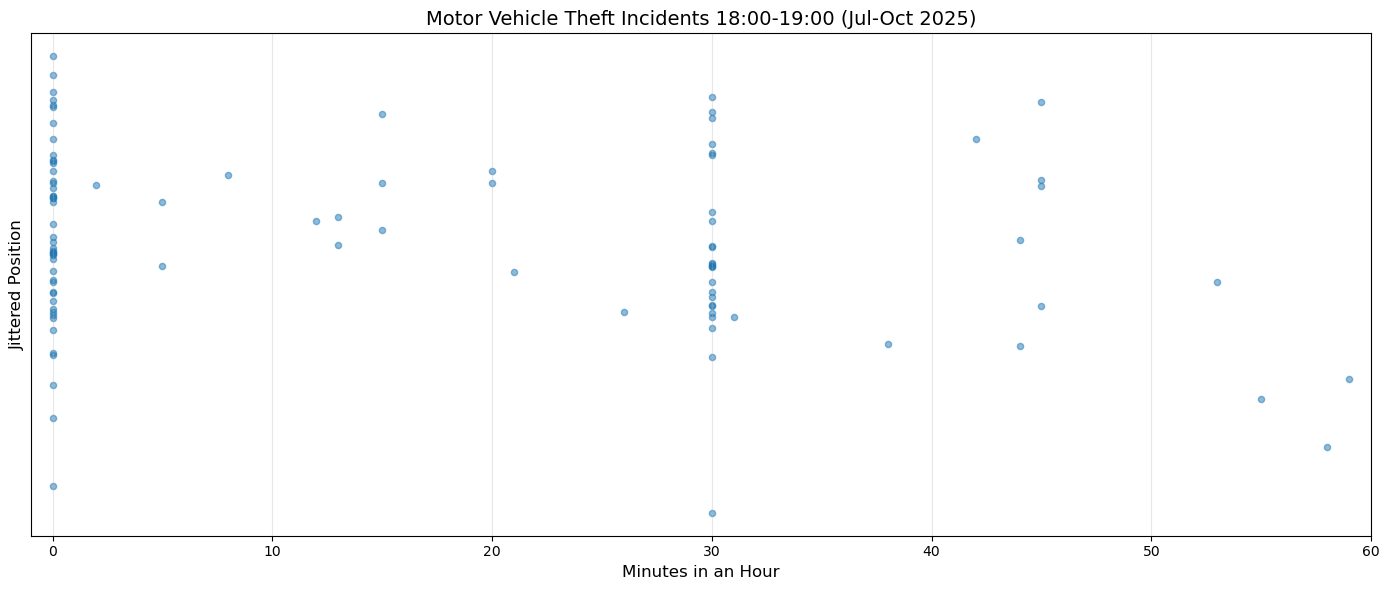

In [35]:
fig, ax = plt.subplots(figsize=(14, 6))

jitter = np.random.normal(0, 0.02, size=len(mvt_filtered))
ax.scatter(mvt_filtered['Minutes'], jitter, alpha=0.5, s=20)

ax.set_xlabel('Minutes in an Hour', fontsize=12)
ax.set_ylabel('Jittered Position', fontsize=12)
ax.set_title('Motor Vehicle Theft Incidents 18:00-19:00 (Jul-Oct 2025)', fontsize=14)
ax.set_xlim(-1, 60)
ax.grid(alpha=0.3, axis='x')
ax.set_yticks([])

plt.tight_layout()
plt.show()

The plot above - Motor Vehicle Theft Incidents 18:00 - 19:00 (Jul - Oct 2025) - shows incidents from a period of 4 months for a selected one hour in a day, allowing to investigate how incidents are registered within a single hour. It is clearly visible that most data points have the time value exactly at 18:00 or 18:30. It may be an effect of rounding up or down the exact time, or considering these hours as 'average' when not knowing real exact time of the incident. This observation suggests that the quality of the time attribute in the dataset is questionable and should be used carefully, perhaps focusing on wider trends rather than within specific hours.

The second plot is a probability plot and addresses the following assignment question:

>
> **Part B — Probability plot**
> * Using the same geographic data from Part B, create a probability plot (QQ plot) for the latitude distribution of each of your two crime types. (`scipy.stats.probplot` is your friend here.)
> * What reference distribution are you comparing against? What would it mean if the points fell exactly on the straight line? Where does the distribution deviate from normal, and what does that deviation tell you about the geography of crime in SF?


First, latitude histogram to understand the distributions.

(12311, 9)


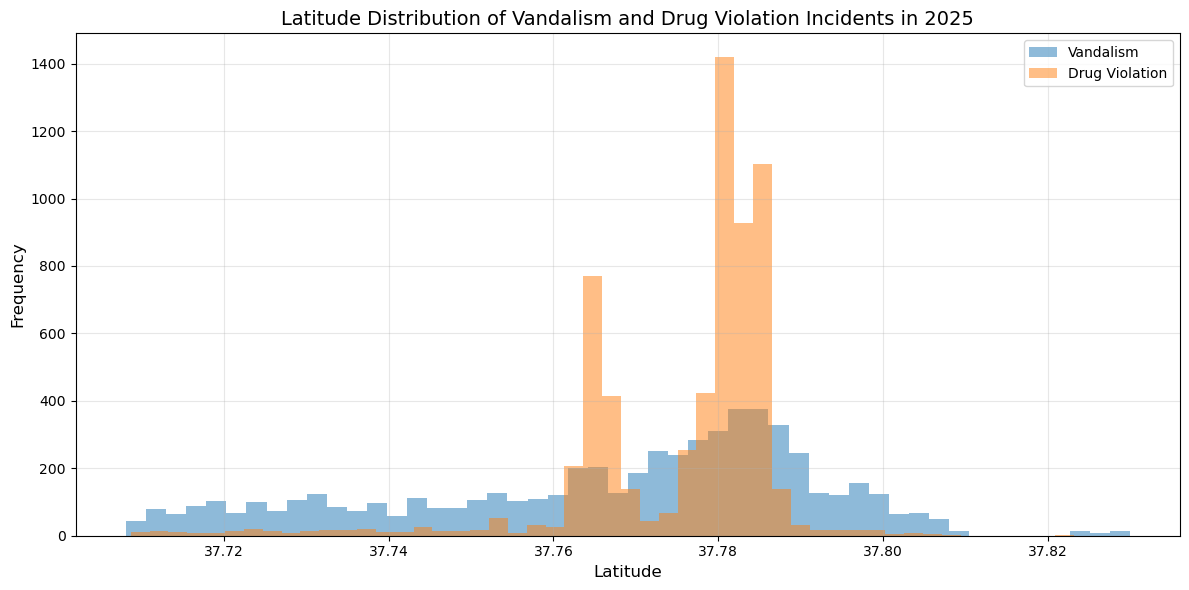

In [36]:
print(df[df['Incident Category'].isin(['Vandalism', 'Drug Violation']) & (df['Incident Year'] == 2025)].shape)

plt.figure(figsize=(12, 6))
plt.hist(df[(df['Incident Category'] == 'Vandalism') & (df['Incident Year'] == 2025)]['Latitude'], bins=50, alpha=0.5, label='Vandalism')
plt.hist(df[(df['Incident Category'] == 'Drug Violation') & (df['Incident Year'] == 2025)]['Latitude'], bins=50, alpha=0.5, label='Drug Violation')
plt.xlabel('Latitude', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Latitude Distribution of Vandalism and Drug Violation Incidents in 2025', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

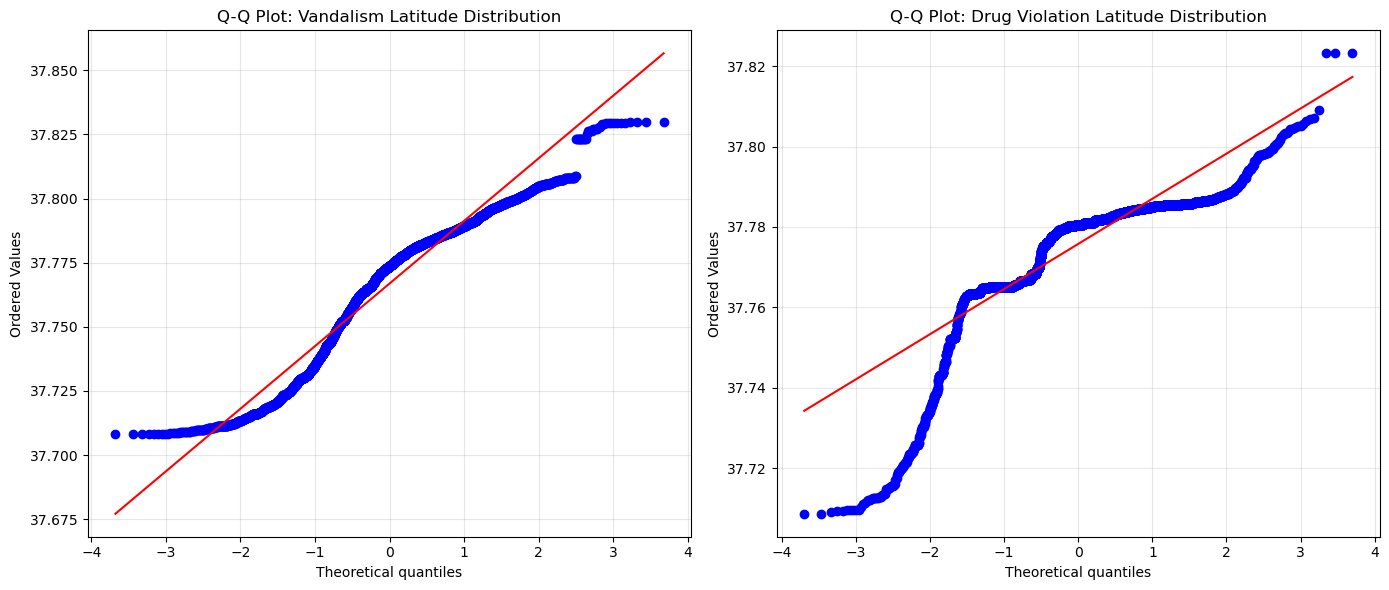

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# QQ plot for Vandalism
vandalism_lat = df[(df['Incident Category'] == 'Vandalism') & (df['Incident Year'] == 2025)]['Latitude']
stats.probplot(vandalism_lat, dist="norm", plot=axes[0])
axes[0].set_title('Q-Q Plot: Vandalism Latitude Distribution', fontsize=12)
axes[0].grid(alpha=0.3)

# QQ plot for Drug Violation
drug_violation_lat = df[(df['Incident Category'] == 'Drug Violation') & (df['Incident Year'] == 2025)]['Latitude']
stats.probplot(drug_violation_lat, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot: Drug Violation Latitude Distribution', fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

The two QQ plots for vandalism and drug violation show how much the distributions of their latitude attribute (blue dots) differ from a normal distribution (red line). The most obvious observation is that the lines formed by blue dots do not overlap with red lines, therefore it could be concluded that latitude for these two crime catgories does not follow a normal distribution, what is confirmed by a histogram plotted above - latitude for vandalism is quite evenly spread, while latitude for drug violation presents a bimodal characterisitcs.

The third visualization is a set of boxplots for every crime category. The charts show the distribution and statistical measures of when crimes occur in a day by defining x-axis as time of the day. This is addressing the following assignment question:


> **Part C — Box plots of time-of-day**
> * For each of your Personal Focus Crimes, extract the time-of-day of every incident.
> * Create box plots showing the time-of-day distribution for all your Personal Focus Crimes side by side.
> * What patterns do you see? Are there crimes that happen mostly at night? Mostly during business hours? For crimes that peak late at night, does the box plot handle the wrap-around at midnight well? What goes wrong?
> * Above, feel free to use alternatives to box plots — violin plots, swarm plots, or raincloud plots — if you think they reveal more. If you do, briefly explain what the alternative shows that the box plot doesn't.

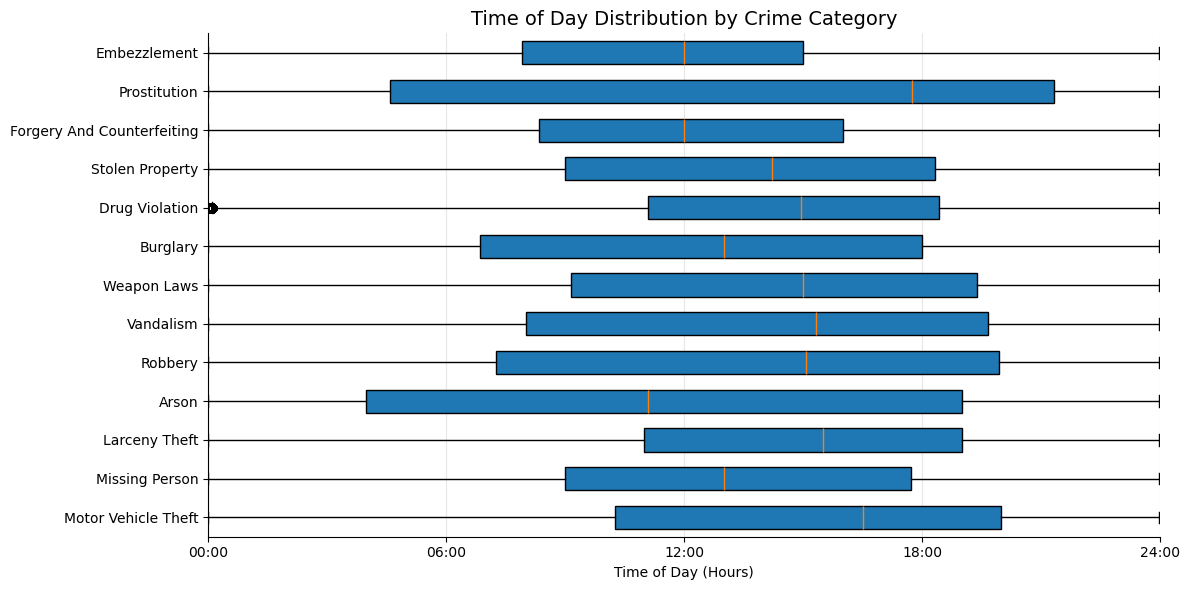

In [38]:
df_datetime['Incident Hour Decimal'] = (df_datetime['Datetime'].dt.hour + df_datetime['Datetime'].dt.minute / 60 + df_datetime['Datetime'].dt.second / 3600)


fig, ax = plt.subplots(figsize=(12, 6))
data = [df_datetime[df_datetime['Incident Category'] == crime]['Incident Hour Decimal'] for crime in df_datetime['Incident Category'].unique()]

ax.boxplot(data, vert=False, patch_artist=True, widths=0.6)

ax.set_yticklabels(df_datetime['Incident Category'].unique())
ax.set_xlabel("Time of Day (Hours)")
ax.set_xlim(0, 24)

ax.set_xticks([0, 6, 12, 18, 24])
ax.set_xticklabels(["00:00", "06:00", "12:00", "18:00", "24:00"])

ax.set_title("Time of Day Distribution by Crime Category", fontsize=14)

ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

For a reference and a meaningful comparison a set of hourly bar plots are created to investigate if the box plots manage to visualize well the time of the day distribution.

In [39]:
df_datetime['Hour'] = df_datetime['Datetime'].dt.hour

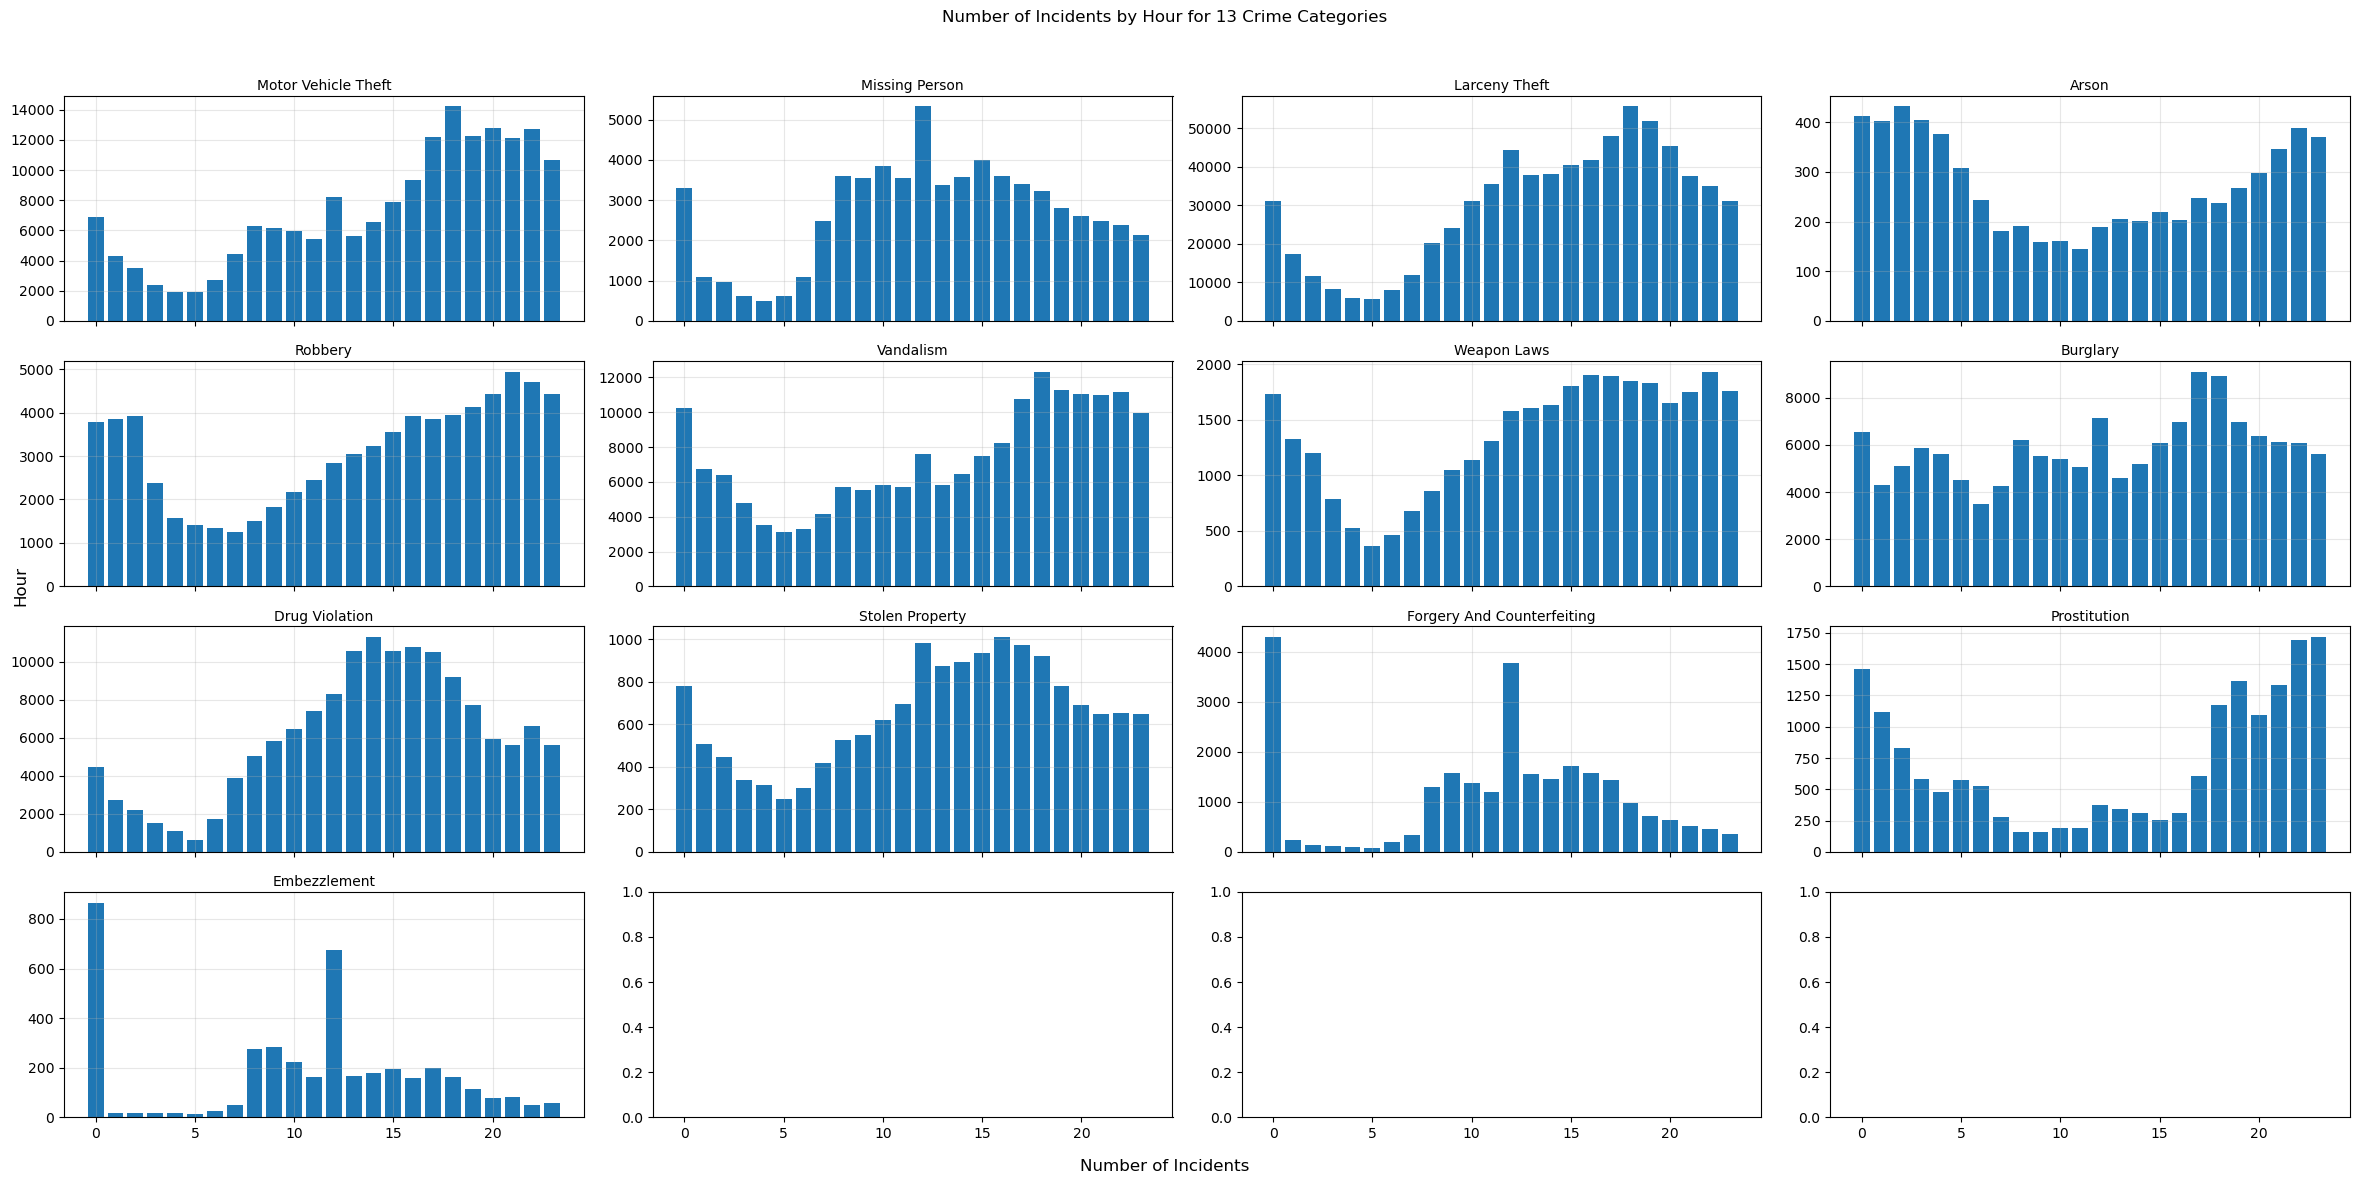

In [40]:
fig, axs = plt.subplots(4, 4, figsize = (24, 12), sharex=True)
fig.suptitle('Number of Incidents by Hour for 13 Crime Categories')
axs = axs.flatten()

for idx, crime in enumerate(df_datetime['Incident Category'].unique()):

    crime_inc_by_hour = df_datetime[df_datetime['Incident Category'] == crime]['Hour'].value_counts().sort_index()
    hours = crime_inc_by_hour.index
    crime_no_inc = crime_inc_by_hour.values
    axs[idx].bar(hours, crime_no_inc)
    axs[idx].set_title(crime, fontsize=10, pad=4)
    axs[idx].grid(alpha=0.3)

fig.supxlabel('Number of Incidents')
fig.supylabel('Hour')
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

The displayed plot shows the hourly distribution of every crime category, and comparing these figures with boxplots in the previous figure, it is clear the boxplots do not visualize the pattern of night peaks, since one part of the night is at the beginning of the x-axis and the other at the end - the plot calculates the mean rather in the middle of the day (or slightly skewed if the peak is early/late in the night).

One of the solutions is to choose a type of a plot that uses categorical values on x-axis, preventing a discontinuation of time (breaking 24-hour cycle). An example would be an hourly plot or aggregation hours into groups such as 'morning', 'afternoon', 'night' that can bear some meaning for a later interpretation. 

# Assignment 1.4 - Spatial Power law

# Assignment 1.5 - Regression and Correlation